# Acceso a API JSON: AEMET

Una opción muy común para bases de datos web es un API en la que realizar consultas. Usualmente se trata de API REST que potencialmente soportan las 4 operaciones CRUD:
* **C**reate (método POST)
* **R**ead (método GET)
* **U**pdate (métodos PUT/PATCH)
* **D**elete (método DELETE)

Sin embargo, no es raro que las bases de datos únicamente soporten la lectura de los datos mediante peticiones HTTP GET. Veamos un ejemplo sencillo para consultar la observación del tiempo meteorológico en AEMET.

La página principal de los datos en abierto de AEMET es https://opendata.aemet.es. En esta web podrás solicitar el API key asociado a tu cuenta de correo (https://opendata.aemet.es/centrodedescargas/altaUsuario?) que es necesario para realizar peticiones. Además, podrás consultar todas las rutas disponibles y los datos que generan (https://opendata.aemet.es/dist/index.html?). Vamos a centrarnos en la **observación convencional** del tiempo actual, que está disponible para su consulta en la ruta **GET /api/observacion/convencional/todas**.

Al realizar una petición con nuestra API key en esta ruta, nos devuelve un documento JSON con información sobre dónde está disponible la información.

In [1]:
# Lee el API de AEMET desde el fichero "api_aemet.txt"
# Solicitar una clave de API y escribirla en ese fichero

with open("api_aemet.txt", "r", encoding='utf-8') as f:
    API_KEY = f.read().strip()

In [2]:
import requests
from pprint import pprint

headers = {'accept': 'application/json', 
           'api_key': API_KEY
          }

r = requests.get("https://opendata.aemet.es/opendata/api/observacion/convencional/todas", headers=headers)
info = r.json()
pprint(info)

{'datos': 'https://opendata.aemet.es/opendata/sh/99f57be7',
 'descripcion': 'exito',
 'estado': 200,
 'metadatos': 'https://opendata.aemet.es/opendata/sh/55c2971b'}


El documento JSON recibido no son los datos en sí, sino un documento que contiene la información para acceder a los metadatos y a los datos. Tanto `info['datos']` como `info[metadatos]` contienen URL para acceder a los documentos JSON con los datos y los metadatos, respectivamente.

In [3]:
datos = requests.get(info['datos']).json()  # Será una lista de diccionarios
metadatos = requests.get(info['metadatos']).json() # Será un diccionario

In [4]:
# Primera observación del tiempo
pprint(datos[0])

{'alt': 32.0,
 'dmax': 3.0,
 'dv': 341.0,
 'fint': '2026-09-24T02:00:00+0000',
 'hr': 75.0,
 'idema': '0002I',
 'lat': 40.95806,
 'lon': 0.871385,
 'prec': 0.0,
 'pres': 1019.1,
 'pres_nmar': 1022.9,
 'stddv': 28.0,
 'stdvv': 0.4,
 'ta': 21.3,
 'tamax': 21.6,
 'tamin': 21.3,
 'tpr': 16.7,
 'ubi': 'VANDELLÓS',
 'vmax': 3.0,
 'vv': 1.2}


In [5]:
# Explicación de los 3 primeros tipos de campos
pprint(metadatos['campos'][:4])

[{'descripcion': 'Indicativo climatógico de la estación meteorológia '
                 'automática',
  'id': 'idema',
  'requerido': True,
  'tipo_datos': 'string'},
 {'descripcion': 'Longitud de la estación meteorológica (grados)',
  'id': 'lon',
  'requerido': True,
  'tipo_datos': 'float'},
 {'descripcion': 'Latitud de la estación meteorológica (grados)',
  'id': 'lat',
  'requerido': True,
  'tipo_datos': 'float'},
 {'descripcion': 'Altitud de la estación en metros',
  'id': 'alt',
  'requerido': True,
  'tipo_datos': 'float'}]


In [6]:
# Como ya tenemos todas los datos, vamos a detectar cuál es la ubicación con la temperatura más alta y más baja de todas las disponibles.

# Importante: seleccionar únicamente las entradas con temperatura y ubicación (claves 'ta' y 'ubi') antes de acceder
print(f'Entradas totales: {len(datos)}')
datos_temp = [(elem['ta'], elem['ubi']) for elem in datos if 'ta' in elem and 'ubi' in elem]
print(f'Entradas filtradas: {len(datos_temp)}')

# Primeras 10 entradas filtradas
print(datos_temp[:10])

Entradas totales: 9727
Entradas filtradas: 9614
[(21.3, 'VANDELLÓS'), (14.1, 'ALFORJA'), (19.0, 'REUS  AEROPUERTO'), (15.9, 'VALLS'), (18.4, 'TARRAGONA  FAC. GEOGRAFIA'), (11.9, 'PONTONS'), (15.7, 'VILAFRANCA DEL PENEDÈS'), (16.1, 'SITGES  VALLCARCA'), (19.8, 'BARCELONA  AEROPUERTO'), (17.3, 'BERGA  INSTITUTO')]


In [7]:
# Ubicación más caliente
print(max(datos_temp))  
# Aprovechamos que el orden de las parejas (x,y) comprueba primero el primer componente (x)

# Ubicación más fría
print(min(datos_temp))
# Aprovechamos que el orden de las parejas (x,y) comprueba primero el primer componente (x)

(37.3, 'SAN NICOLAS T.-TASARTE/COPARLITA')
(3.7, 'CUBILLO DE EBRO')


In [8]:
# Temperaturas en 'SANTIAGO DE COMPOSTELA'
temp_santiago = [(elem['fint'], elem['ta']) 
                   for elem in datos if 
                     'ubi' in elem and 
                     'ta' in elem and
                     elem['ubi'] == 'SANTIAGO DE COMPOSTELA']
pprint(temp_santiago)
print()
pprint(sorted(temp_santiago)) # Ordenamos por primer componente de las parejas (las fechas)

[('2026-09-24T02:00:00+0000', 17.4),
 ('2026-09-24T03:00:00+0000', 16.5),
 ('2026-09-24T04:00:00+0000', 15.8),
 ('2026-09-24T05:00:00+0000', 15.5),
 ('2026-09-24T06:00:00+0000', 14.7),
 ('2026-09-24T07:00:00+0000', 14.2),
 ('2026-09-24T08:00:00+0000', 16.9),
 ('2026-09-24T09:00:00+0000', 19.5),
 ('2026-09-24T10:00:00+0000', 21.4),
 ('2026-09-24T11:00:00+0000', 23.3),
 ('2026-09-24T12:00:00+0000', 25.3),
 ('2026-09-24T13:00:00+0000', 25.1)]

[('2026-09-24T02:00:00+0000', 17.4),
 ('2026-09-24T03:00:00+0000', 16.5),
 ('2026-09-24T04:00:00+0000', 15.8),
 ('2026-09-24T05:00:00+0000', 15.5),
 ('2026-09-24T06:00:00+0000', 14.7),
 ('2026-09-24T07:00:00+0000', 14.2),
 ('2026-09-24T08:00:00+0000', 16.9),
 ('2026-09-24T09:00:00+0000', 19.5),
 ('2026-09-24T10:00:00+0000', 21.4),
 ('2026-09-24T11:00:00+0000', 23.3),
 ('2026-09-24T12:00:00+0000', 25.3),
 ('2026-09-24T13:00:00+0000', 25.1)]


,Fecha,Temperatura
0,2026-09-24 02:00:00+00:00,17.4
1,2026-09-24 03:00:00+00:00,16.5
2,2026-09-24 04:00:00+00:00,15.8
3,2026-09-24 05:00:00+00:00,15.5
4,2026-09-24 06:00:00+00:00,14.7
5,2026-09-24 07:00:00+00:00,14.2
6,2026-09-24 08:00:00+00:00,16.9
7,2026-09-24 09:00:00+00:00,19.5
8,2026-09-24 10:00:00+00:00,21.4
9,2026-09-24 11:00:00+00:00,23.3


Text(0.5, 1.0, 'Temperatura en Santiago de Compostela')

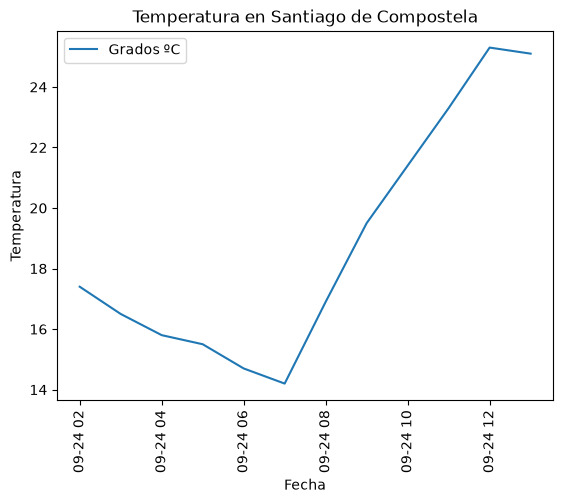

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dibujamos la gráfica de la temperatura observada en las últimas 24h

# 1) Extraemos las temperaturas ordenadas
temp_ord = sorted(temp_santiago)

# 2) Creamos un DataFrame
df_temp = pd.DataFrame(temp_ord, columns=['Fecha', 'Temperatura'])
df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha']) # pasamos a fecha Pandas en lugar de string
display(df_temp)

# 3) Dibujamos la gráfica
sns.lineplot(data=df_temp, x="Fecha", y="Temperatura")
plt.xticks(rotation=90)
plt.legend(labels=["Grados ºC"])
plt.title('Temperatura en Santiago de Compostela')